In [ ]:
# 1. Setup and Installation

# Install required packages
!pip install transformers datasets torch torchvision pillow matplotlib seaborn scikit-learn

In [ ]:
# Upload the zip via a picker
from google.colab import files
up = files.upload()  # choose english_2split_case.zip

# Unzip to /content
import zipfile, io, os
zip_name = next(k for k in up.keys() if k.endswith('.zip'))
with zipfile.ZipFile(io.BytesIO(up[zip_name])) as zf:
    zf.extractall('/content')

# If the zip contains a top-level folder, make sure its name is english_2split_case
!ls -la /content

Saving english_2split_case.zip to english_2split_case.zip
total 13680
drwxr-xr-x 1 root root     4096 Oct  7 00:32 .
drwxr-xr-x 1 root root     4096 Oct  7 00:06 ..
drwxr-xr-x 4 root root     4096 Oct  3 13:36 .config
drwxr-xr-x 4 root root     4096 Oct  7 00:32 english_2split_case
-rw-r--r-- 1 root root 13984308 Oct  7 00:32 english_2split_case.zip
drwxr-xr-x 1 root root     4096 Oct  3 13:36 sample_data


In [ ]:
# 2. Import Libraries

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms, datasets
from transformers import ViTImageProcessor, ViTForImageClassification, TrainingArguments, Trainer
from transformers import EarlyStoppingCallback
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import json
from pathlib import Path
from sklearn.metrics import classification_report, confusion_matrix, f1_score, accuracy_score
from sklearn.metrics import precision_recall_fscore_support
import warnings
warnings.filterwarnings('ignore')

# Check GPU availability
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Using device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")
    print(f"Memory: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")


Using device: cuda
GPU: NVIDIA A100-SXM4-80GB
Memory: 79.3 GB


In [ ]:
# 3. Data Configuration

# Set paths (adjust based on your extracted folder structure)
DATA_ROOT = Path('/content/english_2split_case')  # Adjust if different
TRAIN_DIR = DATA_ROOT / 'train'
TEST_DIR = DATA_ROOT / 'test'
OUTPUT_DIR = Path('/content/vit_results')
OUTPUT_DIR.mkdir(exist_ok=True)

# Verify data structure
print("Data structure:")
print(f"Train directory exists: {TRAIN_DIR.exists()}")
print(f"Test directory exists: {TEST_DIR.exists()}")
if TRAIN_DIR.exists():
    classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])
    print(f"Number of classes: {len(classes)}")
    print(f"First 10 classes: {classes[:10]}")

Data structure:
Train directory exists: True
Test directory exists: True
Number of classes: 62
First 10 classes: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']


In [ ]:
# 4. Custom Dataset Class for ViT

class HandwrittenCharacterDataset(Dataset):
    def __init__(self, data_dir, processor, is_train=True):
        self.data_dir = Path(data_dir)
        self.processor = processor
        self.is_train = is_train

        # Get all image paths and labels
        self.image_paths = []
        self.labels = []
        self.class_to_idx = {}
        self.idx_to_class = {}

        # Build class mappings
        class_names = sorted([d.name for d in self.data_dir.iterdir() if d.is_dir()])
        for idx, class_name in enumerate(class_names):
            self.class_to_idx[class_name] = idx
            self.idx_to_class[idx] = class_name

        # Collect all image paths
        for class_name in class_names:
            class_dir = self.data_dir / class_name
            class_idx = self.class_to_idx[class_name]

            for img_path in class_dir.glob('*'):
                if img_path.suffix.lower() in ['.jpg', '.jpeg', '.png', '.bmp']:
                    self.image_paths.append(img_path)
                    self.labels.append(class_idx)

        print(f"Dataset loaded: {len(self.image_paths)} images, {len(class_names)} classes")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]

        # Load and process image
        try:
            image = Image.open(img_path)

            # Convert to RGB if needed
            if image.mode != 'RGB':
                image = image.convert('RGB')

            # Resize to 224x224 for ViT
            image = image.resize((224, 224), Image.Resampling.LANCZOS)

            # Process with ViT processor
            processed = self.processor(images=image, return_tensors="pt")
            pixel_values = processed['pixel_values'].squeeze()

            return {
                'pixel_values': pixel_values,
                'labels': torch.tensor(label, dtype=torch.long)
            }

        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            # Return a dummy tensor in case of error
            dummy_image = torch.zeros((3, 224, 224))
            return {
                'pixel_values': dummy_image,
                'labels': torch.tensor(label, dtype=torch.long)
            }

In [ ]:
# 5. Model Setup

# Initialize ViT processor and model
model_name = "google/vit-base-patch16-224"
processor = ViTImageProcessor.from_pretrained(model_name)

# Create datasets
train_dataset = HandwrittenCharacterDataset(TRAIN_DIR, processor, is_train=True)
test_dataset = HandwrittenCharacterDataset(TEST_DIR, processor, is_train=False)

# Ensure both datasets have the same class mappings
test_dataset.class_to_idx = train_dataset.class_to_idx
test_dataset.idx_to_class = train_dataset.idx_to_class

num_classes = len(train_dataset.class_to_idx)
print(f"Number of classes: {num_classes}")

# Initialize model with correct number of classes
model = ViTForImageClassification.from_pretrained(
    model_name,
    num_labels=num_classes,
    ignore_mismatched_sizes=True
)


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

Dataset loaded: 2728 images, 62 classes
Dataset loaded: 682 images, 62 classes
Number of classes: 62


config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Some weights of ViTForImageClassification were not initialized from the model checkpoint at google/vit-base-patch16-224 and are newly initialized because the shapes did not match:
- classifier.bias: found shape torch.Size([1000]) in the checkpoint and torch.Size([62]) in the model instantiated
- classifier.weight: found shape torch.Size([1000, 768]) in the checkpoint and torch.Size([62, 768]) in the model instantiated
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [ ]:
# 6. Training Configuration

# Training arguments
training_args = TrainingArguments(
    output_dir=str(OUTPUT_DIR / 'checkpoints'),
    num_train_epochs=20,
    per_device_train_batch_size=16,
    per_device_eval_batch_size=16,
    warmup_steps=500,
    weight_decay=0.01,
    logging_dir=str(OUTPUT_DIR / 'logs'),
    logging_steps=50,
    eval_strategy="epoch", # Changed from evaluation_strategy
    save_strategy="epoch",
    load_best_model_at_end=True,
    metric_for_best_model="accuracy",
    greater_is_better=True,
    save_total_limit=3,
    remove_unused_columns=False,
    push_to_hub=False,
    report_to="none",  # Explicitly disable wandb
    dataloader_pin_memory=False,  # Can help with memory issues
)

In [ ]:
# 7. Metrics and Evaluation Functions

def compute_metrics(eval_pred):
    predictions, labels = eval_pred
    predictions = np.argmax(predictions, axis=1)

    accuracy = accuracy_score(labels, predictions)
    precision, recall, f1, _ = precision_recall_fscore_support(labels, predictions, average='weighted')

    return {
        'accuracy': accuracy,
        'f1': f1,
        'precision': precision,
        'recall': recall
    }

# Custom data collator
def collate_fn(batch):
    pixel_values = torch.stack([item['pixel_values'] for item in batch])
    labels = torch.stack([item['labels'] for item in batch])
    return {
        'pixel_values': pixel_values,
        'labels': labels
    }


In [ ]:
# 8. Trainer Setup and Training

# Initialize trainer
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=train_dataset,
    eval_dataset=test_dataset,
    compute_metrics=compute_metrics,
    data_collator=collate_fn,
    callbacks=[] # EarlyStoppingCallback(early_stopping_patience=3)
)

# Train the model
print("Starting training...")
trainer.train()


Starting training...


Epoch,Training Loss,Validation Loss,Accuracy,F1,Precision,Recall
1,3.538900,2.891604,0.489736,0.462965,0.543632,0.489736
2,1.525900,0.970315,0.825513,0.820309,0.852018,0.825513
3,0.510200,0.601246,0.826979,0.812251,0.842204,0.826979
4,0.316500,0.449787,0.863636,0.858827,0.868138,0.863636
5,0.210900,0.416583,0.868035,0.865325,0.883098,0.868035
6,0.106200,0.434292,0.876833,0.875395,0.885767,0.876833
7,0.054300,0.429464,0.876833,0.876808,0.889189,0.876833
8,0.032700,0.465745,0.887097,0.885668,0.898155,0.887097
9,0.025300,0.449485,0.888563,0.887356,0.898745,0.888563
10,0.002900,0.470265,0.885630,0.884738,0.895592,0.885630


TrainOutput(global_step=3420, training_loss=0.3469954936166038, metrics={'train_runtime': 2232.7254, 'train_samples_per_second': 24.437, 'train_steps_per_second': 1.532, 'total_flos': 4.2302365870502707e+18, 'train_loss': 0.3469954936166038, 'epoch': 20.0})

In [ ]:
# 10. Final Evaluation

# Evaluate on test set
print("Evaluating on test set...")
test_results = trainer.evaluate(eval_dataset=test_dataset)
print("Test Results:")
for key, value in test_results.items():
    print(f"  {key}: {value:.4f}")

# Get detailed predictions for confusion matrix
model.eval()
test_dataloader = DataLoader(test_dataset, batch_size=16, shuffle=False, collate_fn=collate_fn)

all_predictions = []
all_labels = []

with torch.no_grad():
    for batch in test_dataloader:
        pixel_values = batch['pixel_values'].to(device)
        labels = batch['labels'].to(device)

        outputs = model(pixel_values=pixel_values)
        predictions = torch.argmax(outputs.logits, dim=-1)

        all_predictions.extend(predictions.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

Evaluating on test set...


Test Results:
  eval_loss: 0.4750
  eval_accuracy: 0.8915
  eval_f1: 0.8907
  eval_precision: 0.9003
  eval_recall: 0.8915
  eval_runtime: 19.6213
  eval_samples_per_second: 34.7580
  eval_steps_per_second: 2.1910
  epoch: 20.0000



Detailed Classification Report:
              precision    recall  f1-score   support

           0       0.43      0.27      0.33        11
           1       0.89      0.73      0.80        11
           2       1.00      1.00      1.00        11
           3       0.91      0.91      0.91        11
           4       0.92      1.00      0.96        11
           5       0.91      0.91      0.91        11
           6       1.00      1.00      1.00        11
           7       0.92      1.00      0.96        11
           8       1.00      1.00      1.00        11
           9       0.91      0.91      0.91        11
         L_a       1.00      0.82      0.90        11
         L_b       1.00      0.91      0.95        11
         L_c       0.67      0.91      0.77        11
         L_d       0.91      0.91      0.91        11
         L_e       1.00      0.82      0.90        11
         L_f       1.00      0.73      0.84        11
         L_g       0.85      1.00      0.92     

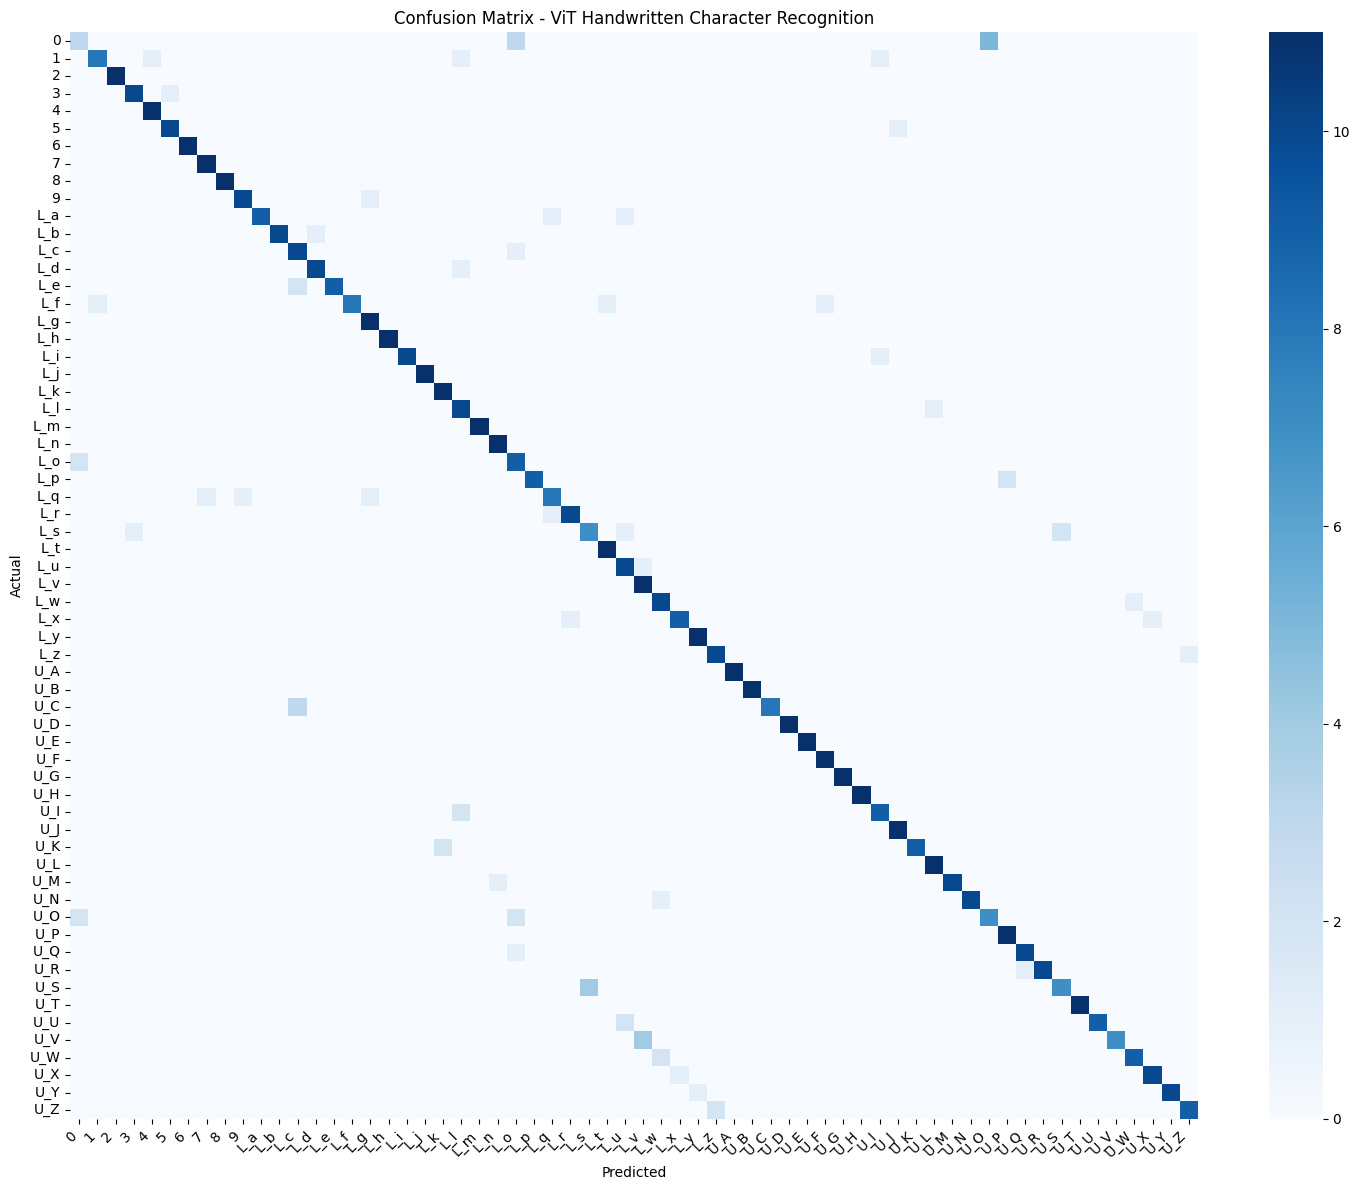


FINAL RESULTS
Test Accuracy: 0.8915
Weighted F1-Score: 0.8907
Macro F1-Score: 0.8907
Number of Classes: 62
Total Test Samples: 682


In [ ]:
# 11. Visualization and Analysis

# Classification report
class_names = [train_dataset.idx_to_class[i] for i in range(num_classes)]
report = classification_report(all_labels, all_predictions, target_names=class_names)
print("\nDetailed Classification Report:")
print(report)

# Save classification report
with open(OUTPUT_DIR / 'classification_report.txt', 'w') as f:
    f.write(report)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_predictions)

# Plot confusion matrix
plt.figure(figsize=(15, 12))
sns.heatmap(cm, annot=False, fmt='d', cmap='Blues',
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - ViT Handwritten Character Recognition')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / 'confusion_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

# Calculate and display final metrics
final_accuracy = accuracy_score(all_labels, all_predictions)
final_f1 = f1_score(all_labels, all_predictions, average='weighted')
macro_f1 = f1_score(all_labels, all_predictions, average='macro')

print(f"\n{'='*50}")
print("FINAL RESULTS")
print(f"{'='*50}")
print(f"Test Accuracy: {final_accuracy:.4f}")
print(f"Weighted F1-Score: {final_f1:.4f}")
print(f"Macro F1-Score: {macro_f1:.4f}")
print(f"Number of Classes: {num_classes}")
print(f"Total Test Samples: {len(all_labels)}")

# Save final metrics
final_metrics = {
    'test_accuracy': float(final_accuracy),
    'weighted_f1': float(final_f1),
    'macro_f1': float(macro_f1),
    'num_classes': num_classes,
    'total_test_samples': len(all_labels),
    'model_name': model_name,
    'training_epochs': training_args.num_train_epochs,
    'batch_size': training_args.per_device_train_batch_size
}

with open(OUTPUT_DIR / 'final_metrics.json', 'w') as f:
    json.dump(final_metrics, f, indent=2)



Generating sample predictions visualization...


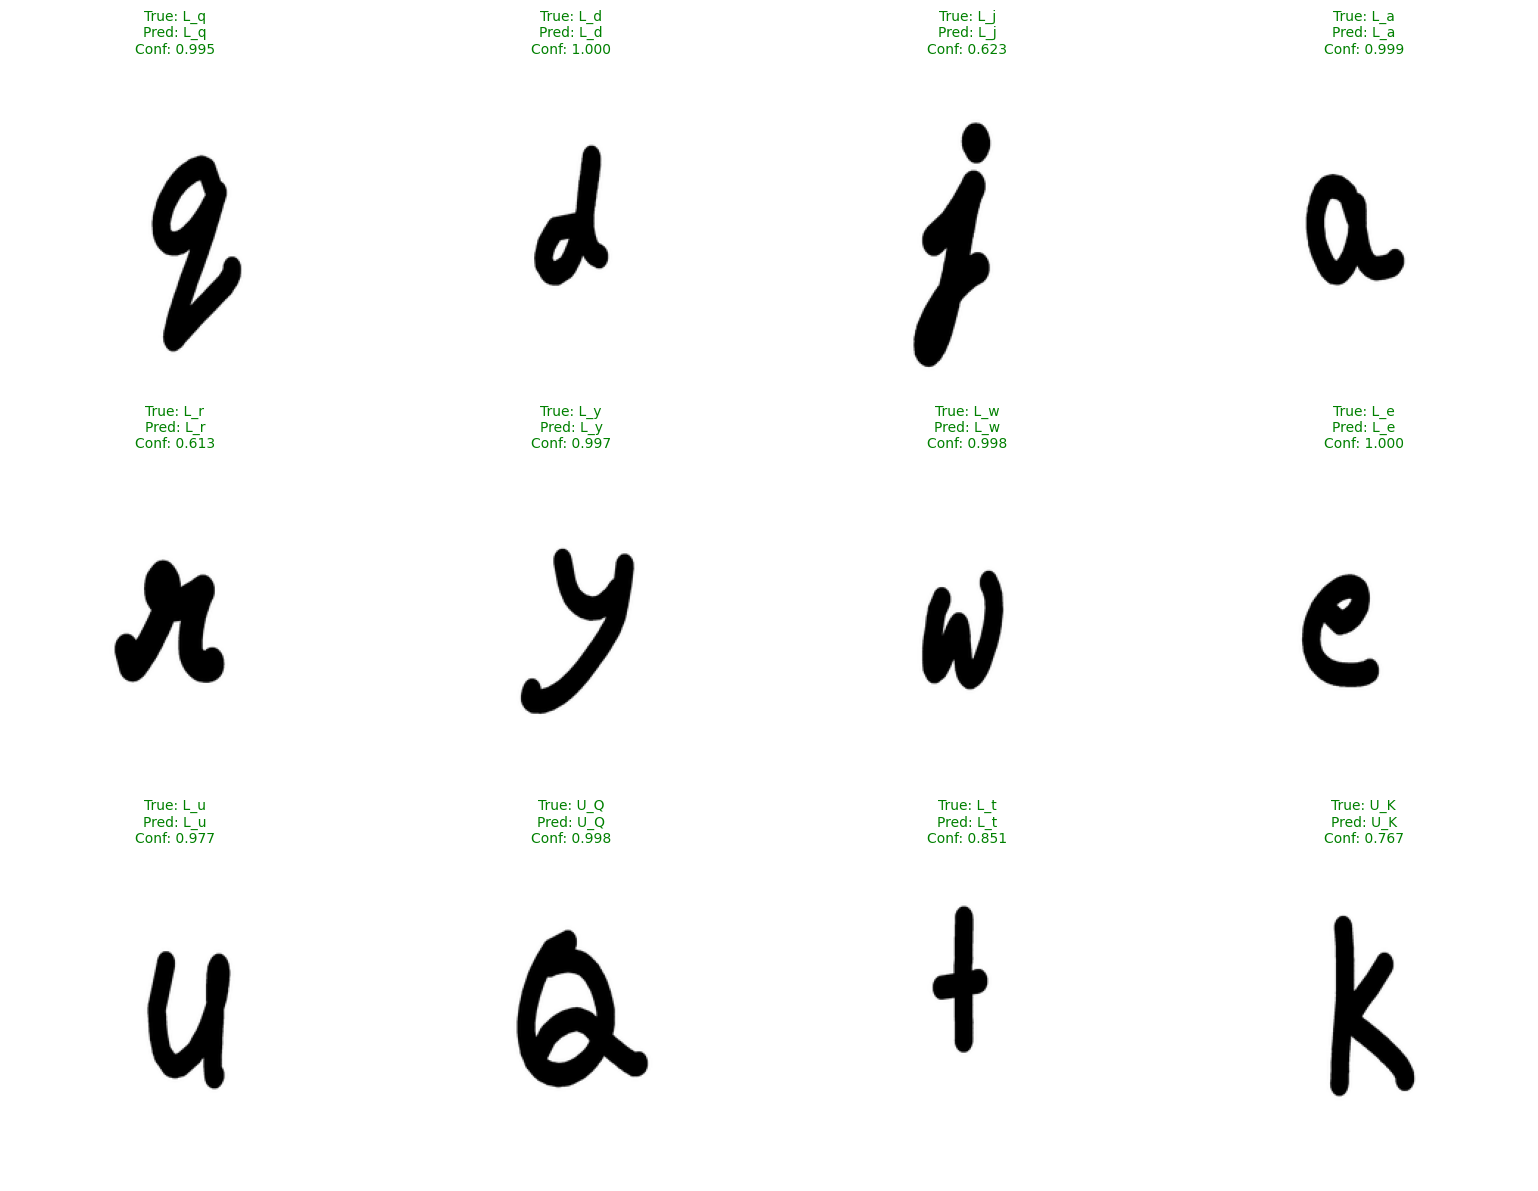


All results saved to: /content/vit_results
Files created:
  - checkpoints
  - confusion_matrix.png
  - final_metrics.json
  - classification_report.txt
  - sample_predictions.png


In [ ]:
# 12. Sample Predictions Visualization

def visualize_predictions(dataset, model, processor, num_samples=12):
    """Visualize sample predictions"""
    model.eval()

    # Get random samples
    indices = np.random.choice(len(dataset), num_samples, replace=False)

    fig, axes = plt.subplots(3, 4, figsize=(16, 12))
    axes = axes.ravel()

    for i, idx in enumerate(indices):
        # Get image and true label
        sample = dataset[idx]
        pixel_values = sample['pixel_values'].unsqueeze(0).to(device)
        true_label = sample['labels'].item()
        true_class = dataset.idx_to_class[true_label]

        # Get prediction
        with torch.no_grad():
            outputs = model(pixel_values=pixel_values)
            predicted_label = torch.argmax(outputs.logits, dim=-1).item()
            predicted_class = dataset.idx_to_class[predicted_label]
            confidence = torch.softmax(outputs.logits, dim=-1).max().item()

        # Convert tensor to displayable image
        img_tensor = sample['pixel_values']
        img_array = img_tensor.permute(1, 2, 0).numpy()
        img_array = (img_array - img_array.min()) / (img_array.max() - img_array.min())

        # Plot
        axes[i].imshow(img_array)
        axes[i].axis('off')

        color = 'green' if true_label == predicted_label else 'red'
        title = f'True: {true_class}\nPred: {predicted_class}\nConf: {confidence:.3f}'
        axes[i].set_title(title, color=color, fontsize=10)

    plt.tight_layout()
    plt.savefig(OUTPUT_DIR / 'sample_predictions.png', dpi=300, bbox_inches='tight')
    plt.show()

# Generate sample predictions visualization
print("\nGenerating sample predictions visualization...")
visualize_predictions(test_dataset, model, processor)

print(f"\nAll results saved to: {OUTPUT_DIR}")
print("Files created:")
for file in OUTPUT_DIR.glob('*'):
    print(f"  - {file.name}")

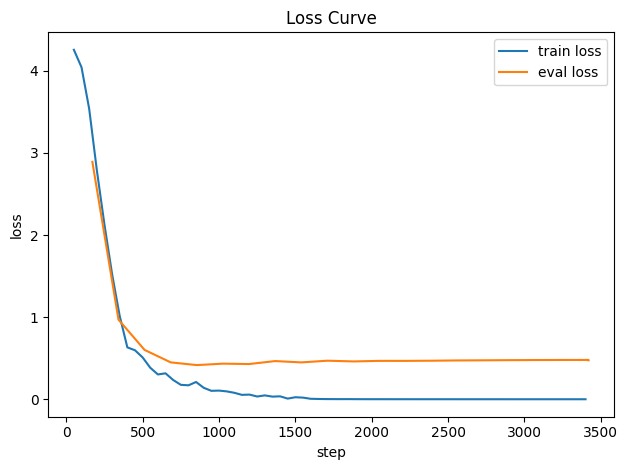

Saved: /content/vit_results/loss_curve.png


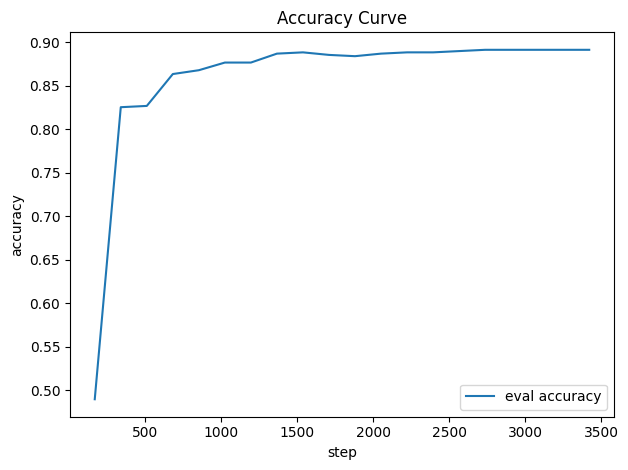

Saved: /content/vit_results/accuracy_curve.png


In [ ]:
# Plot Training/Eval Loss & Accuracy Curves (Hugging Face Trainer)

from pathlib import Path
import json
import matplotlib.pyplot as plt

def _collect_log_history(trainer=None, output_dir=None):
    log_history = []
    # Option A: use in-memory Trainer state if available
    if trainer is not None and getattr(trainer, "state", None) is not None:
        if getattr(trainer.state, "log_history", None):
            log_history = list(trainer.state.log_history)
    # Option B: read saved trainer_state.json
    if not log_history and output_dir is not None:
        state_file = Path(output_dir) / "trainer_state.json"
        if state_file.exists():
            with open(state_file, "r", encoding="utf-8") as f:
                state = json.load(f)
            log_history = state.get("log_history", [])
    return log_history

# Resolve output_dir
try:
    _OUTPUT_DIR = Path(OUTPUT_DIR)
except NameError:
    try:
        _OUTPUT_DIR = Path(training_args.output_dir)
    except Exception:
        _OUTPUT_DIR = Path("./vit_results")
_OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

# Resolve trainer reference (if defined earlier)
try:
    _trainer_ref = trainer
except NameError:
    _trainer_ref = None

logs = _collect_log_history(trainer=_trainer_ref, output_dir=_OUTPUT_DIR)

if not logs:
    print("No log history found. Run training first, or ensure 'trainer_state.json' exists in:", _OUTPUT_DIR)
else:
    # Collect metrics
    train_steps, train_loss = [], []
    eval_loss_steps, eval_loss_vals = [], []
    eval_acc_steps,  eval_acc_vals  = [], []

    for e in logs:
        # Training loss entries
        if "loss" in e and not ("eval_loss" in e or "eval_accuracy" in e):
            train_steps.append(e.get("step"))
            train_loss.append(e["loss"])
        # Eval loss entries
        if "eval_loss" in e:
            eval_loss_steps.append(e.get("step"))
            eval_loss_vals.append(e["eval_loss"])
        # Eval accuracy entries (requires compute_metrics returning accuracy)
        if "eval_accuracy" in e:
            eval_acc_steps.append(e.get("step"))
            eval_acc_vals.append(e["eval_accuracy"])

    # Normalize steps if None (fallback to simple indices)
    if any(s is None for s in train_steps):
        train_steps = list(range(len(train_loss)))
    if any(s is None for s in eval_loss_steps):
        eval_loss_steps = list(range(len(eval_loss_vals)))
    if any(s is None for s in eval_acc_steps):
        eval_acc_steps = list(range(len(eval_acc_vals)))

    # -------- Plot: Loss (train + eval) --------
    if train_loss or eval_loss_vals:
        plt.figure()
        if train_loss:
            plt.plot(train_steps, train_loss, label="train loss")
        if eval_loss_vals:
            plt.plot(eval_loss_steps, eval_loss_vals, label="eval loss")
        plt.xlabel("step")
        plt.ylabel("loss")
        plt.title("Loss Curve")
        plt.legend()
        plt.tight_layout()
        loss_path = _OUTPUT_DIR / "loss_curve.png"
        plt.savefig(loss_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved:", loss_path)

    # -------- Plot: Accuracy (eval only) --------
    if eval_acc_vals:
        plt.figure()
        plt.plot(eval_acc_steps, eval_acc_vals, label="eval accuracy")
        plt.xlabel("step")
        plt.ylabel("accuracy")
        plt.title("Accuracy Curve")
        plt.legend()
        plt.tight_layout()
        acc_path = _OUTPUT_DIR / "accuracy_curve.png"
        plt.savefig(acc_path, dpi=200, bbox_inches="tight")
        plt.show()
        print("Saved:", acc_path)
    else:
        print("No 'eval_accuracy' found in logs. Ensure your Trainer was created with compute_metrics that returns accuracy.")
